In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import estatistica as es

In [2]:
hoteis = pd.read_csv('./csv/tratado/hoteis_tratado.csv')
quartos = pd.read_csv('./csv/tratado/quartos_tratado.csv')
hospedes = pd.read_csv('./csv/tratado/hospedes_tratado.csv')
avaliacoes = pd.read_csv('./csv/tratado/avaliacoes_tratado.csv')
reservas = pd.read_csv('./csv/tratado/reservas_tratado.csv')

reservas.head()

,id_reserva,id_hospede,id_quarto,id_hotel,data_checkin,data_checkout,canal_reserva,valor_diaria,status_reserva,data_reserva
0,1,203,26,3,2024-10-28,2024-10-29,Site Próprio,2344.25,Confirmada,2024-10-21
1,2,30,33,3,2024-06-03,2024-06-07,Site Próprio,469.17,Confirmada,2024-05-07
2,3,47,4,1,2024-07-18,2024-07-25,Site Próprio,2358.47,Confirmada,2024-07-10
3,4,322,23,2,2024-08-19,2024-08-20,Telefone,1743.13,Confirmada,2024-08-15
4,5,286,13,2,2023-05-17,2023-05-22,Agência de Viagem,617.85,Confirmada,2023-05-09


In [3]:
reservas['mes_ano_reserva'] = reservas['data_reserva'].astype(str)
reservas['mes_ano_reserva'] = reservas['data_reserva'].str.slice(0, 7)
reservas.head()

,id_reserva,id_hospede,id_quarto,id_hotel,data_checkin,data_checkout,canal_reserva,valor_diaria,status_reserva,data_reserva,mes_ano_reserva
0,1,203,26,3,2024-10-28,2024-10-29,Site Próprio,2344.25,Confirmada,2024-10-21,2024-10
1,2,30,33,3,2024-06-03,2024-06-07,Site Próprio,469.17,Confirmada,2024-05-07,2024-05
2,3,47,4,1,2024-07-18,2024-07-25,Site Próprio,2358.47,Confirmada,2024-07-10,2024-07
3,4,322,23,2,2024-08-19,2024-08-20,Telefone,1743.13,Confirmada,2024-08-15,2024-08
4,5,286,13,2,2023-05-17,2023-05-22,Agência de Viagem,617.85,Confirmada,2023-05-09,2023-05


## Medida Central

Média do valor da diária: R$1.617,09  
Mediana do valor da diária: R$1.563,45  
Distância entre média e mediana: __3,4%__  

A distância entre média e mediana é de aproximadamente 3,4%, portanto a média é um valor válido para media central.

In [4]:
media = es.calc_media(reservas, 'valor_diaria')
mediana = es.calc_mediana(reservas, 'valor_diaria')
distancia = es.calc_distancia(reservas, 'valor_diaria')
print(f'Média: {media}')
print(f'Mediana: {mediana}')
print(f'Distância: {distancia}')

Média: 1617.0970257452575
Mediana: 1563.455
Distância: 0.03430992625004082


## Valores Atípicos

IQR: R$1.269,82
Limite Superior: R$4.092,81  
Limite Inferior: -R$986,46  

### Outliers
Foram encontrados 5 outliers, com valores acima do limite superior. Reservas com os seguintes IDs: 34, 178, 321, 512 e 689

In [5]:
iqr = es.calc_iqr(reservas, 'valor_diaria')
lim_sup = es.calc_limites(reservas, 'valor_diaria')[1]
lim_inf = es.calc_limites(reservas, 'valor_diaria')[0]

print(f'IQR valor diária: {iqr}')
print(f'Limite superior: {lim_sup}')
print(f'Limite inferior: {lim_inf}')

IQR valor diária: 1269.8200000000002
Limite superior: 4092.8125
Limite inferior: -986.4675000000003


In [6]:
outliers_reservas = reservas.loc[reservas['valor_diaria'] > es.calc_limites(reservas, 'valor_diaria')[1]]
outliers_reservas = outliers_reservas.sort_values(by='valor_diaria')
outliers_reservas['id_reserva'] = outliers_reservas['id_reserva'].astype(str)

In [7]:
outliers_reservas = outliers_reservas.merge(
    hoteis[['id_hotel', 'nome_hotel']],
    on='id_hotel',
    how='inner'
)

## Desempenho por Canal de Vendas

Expedia: __R$514.059,27__  
Booking.com: R$506.550,61  
Site Próprio: R$488.102,78  
Agência de Viagem: R$428.237,12  
Telefone: R$428.744,92  

O canal de vendas com maior ticket médio: Expedia

In [26]:
canal_maior_ticket = reservas.groupby('canal_reserva')['valor_diaria'].sum().reset_index().sort_values(by='valor_diaria')
canal_maior_ticket

,canal_reserva,valor_diaria
3,Não informado,21140.51
5,Telefone,428237.12
0,Agência de Viagem,428744.92
4,Site Próprio,488102.78
1,Booking.com,506550.61
2,Expedia,514059.27


## Overbooking

Nara Recife: __16__  
Nara Salvador: 10  
Nara Rio de Janeiro: 9  
Nara São Paulo: 7  
Nara Fortaleza: 3  

In [21]:
overbooking = reservas.loc[reservas['status_reserva'] == 'Overbooking']
overbooking = overbooking.groupby(['id_hotel'])['status_reserva'].count().reset_index().sort_values(by='id_hotel')
overbooking['id_hotel'] = overbooking['id_hotel'].astype(str)

In [10]:
hoteis

,id_hotel,nome_hotel,cidade,estado,categoria,n_quartos
0,1,Nara Fortaleza,Fortaleza,CE,5 estrelas,12
1,2,Nara Recife,Recife,PE,4 estrelas,11
2,3,Nara Salvador,Salvador,BA,4 estrelas,11
3,4,Nara Rio de Janeiro,Rio de Janeiro,RJ,3 estrelas,10
4,5,Nara São Paulo,São Paulo,SP,5 estrelas,13


In [11]:
reservas_mes_ano = reservas.groupby('mes_ano_reserva')['id_reserva'].count().reset_index().sort_values(by='id_reserva', ascending=False)
reservas_mes_ano['id_reserva'] = reservas_mes_ano['id_reserva']

In [33]:
valor_tipo_quarto = quartos.groupby('tipo_quarto')['valor_base'].median().reset_index().sort_values(by='valor_base', ascending=False)

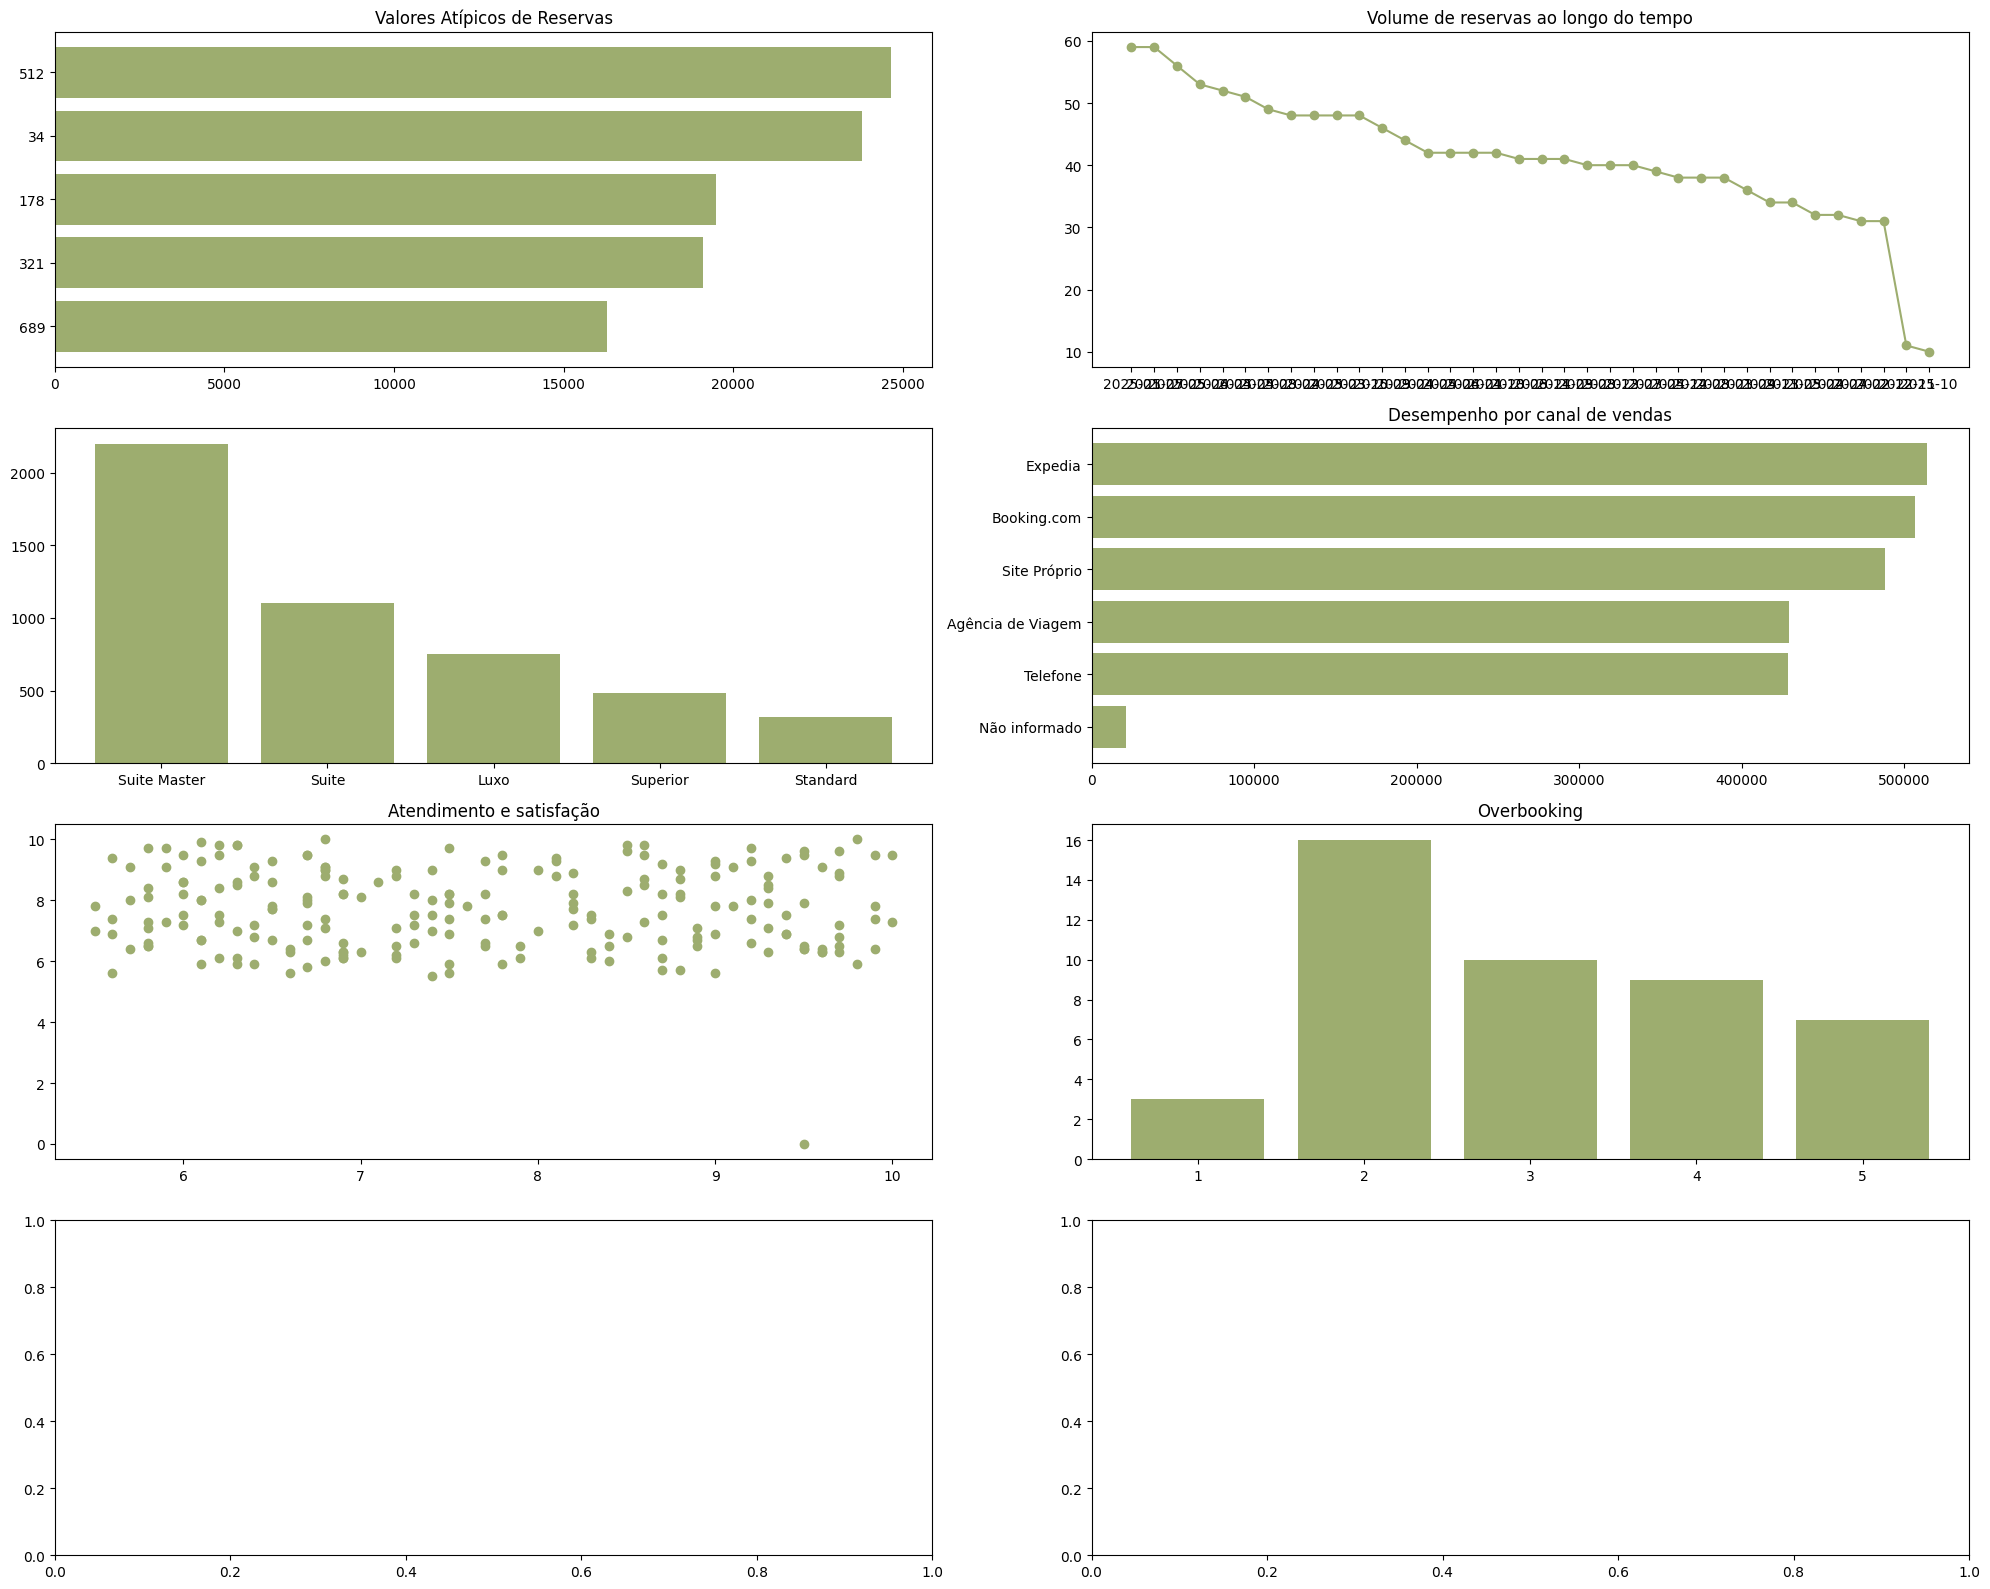

In [35]:
fig, axs = plt.subplots(4, 2, figsize=(20, 16))

axs[0, 0].barh(outliers_reservas['id_reserva'], outliers_reservas['valor_diaria'], color='#9dad6f')
axs[0, 0].set_title('Valores Atípicos de Reservas')

axs[0, 1].plot(reservas_mes_ano['mes_ano_reserva'], reservas_mes_ano['id_reserva'], marker='o', color='#9dad6f')
axs[0, 1].set_title('Volume de reservas ao longo do tempo')

axs[1, 0].bar(valor_tipo_quarto['tipo_quarto'], valor_tipo_quarto['valor_base'], color='#9dad6f')

axs[1, 1].barh(canal_maior_ticket['canal_reserva'], canal_maior_ticket['valor_diaria'], color='#9dad6f')
axs[1, 1].set_title('Desempenho por canal de vendas')

axs[2, 0].scatter(avaliacoes['nota_geral'], avaliacoes['nota_atendimento'], color='#9dad6f')
axs[2, 0].set_title('Atendimento e satisfação')

axs[2, 1].bar(overbooking['id_hotel'], overbooking['status_reserva'], color='#9dad6f')
axs[2, 1].set_title('Overbooking')

plt.tight_layout()